# Stylizing ViT - Data Augmentation Demo

This notebook demonstrates how to use **Stylizing ViT** as a test-time augmentation (TTA) or training-time augmentation tool to improve domain generalization.

The core idea is to take a batch of images and stylize them using styles extracted from either the same batch (shuffling) or a reference style bank.

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
import requests

from stylizing_vit import create_model
from stylizing_vit.util import denormalize_image

In [32]:
import random
import numpy as np

# Set seeds for reproducibility
SEED = 10
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"Random seed set to {SEED}")

Random seed set to 10


## 1. Define the Style Augmentation Module

We wrap the `StylizingViT` model in a module that can be easily plugged into a training loop.

In [33]:
class StylizingAugmentation(nn.Module):
    def __init__(self, backbone="small", weights="fitzpatrick17k_12_34_56", device="cuda"):
        super().__init__()
        self.device = device
        self.model = create_model(backbone=backbone, weights=weights, train=False)
        self.model.to(device)
        self.model.eval()
        
        # Freeze the stylizer (we only use it for inference)
        for param in self.model.parameters():
            param.requires_grad = False

    def forward(self, x):
        """
        Args:
            x (torch.Tensor): Batch of images (B, 3, H, W).
        Returns:
            torch.Tensor: Batch of stylized images.
        """
        B = x.shape[0]
        
        # Create style targets by shuffling the batch (intra-batch stylization)
        # This forces the model to mix anatomy of image i with style of image j
        x_style = x.clone().roll(shifts=-1, dims=0)
        
        with torch.no_grad():
            # StylizingViT takes (content, style)
            x_stylized = self.model(x, x_style)
            
        return x_stylized, x_style

## 2. Load Sample Data

We download a few random images to simulate a batch.

In [34]:
def get_image(url):
    resp = requests.get(url, stream=True, headers={"User-Agent": "Mozilla/5.0"})
    img = Image.open(resp.raw).convert('RGB')
    return img

# Sample URLs from Fitzpatrick17k dataset
urls = [
    "https://www.dermaamin.com/site/images/clinical-pic/s/scleromyxedema/scleromyxedema67.jpg",
    "https://www.dermaamin.com/site/images/clinical-pic/t/trauma/trauma7.jpg",
    "https://www.dermaamin.com/site/images/clinical-pic/e/eczema/eczema65.jpg",
    "http://atlasdermatologico.com.br/img?imageId=1702"
]

# Get dataset mean and std
DATASET_MEAN = (0.6219, 0.4917, 0.4478)
DATASET_STD = (0.2279, 0.1982, 0.1991)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=DATASET_MEAN, std=DATASET_STD)
])

batch_images = []
print("Downloading images...")
for url in urls:
    try:
        img = get_image(url)
        batch_images.append(transform(img))
    except Exception as e:
        print(f"Failed to load {url}: {e}")

if not batch_images:
    raise ValueError("No images loaded. Check internet connection.")

# Create a batch (B, 3, 224, 224)
batch_tensor = torch.stack(batch_images).to("cuda" if torch.cuda.is_available() else "cpu")
print(f"Created batch of shape {batch_tensor.shape}")

Created batch of shape torch.Size([4, 3, 224, 224])


## 3. Apply Augmentation

We pass the batch through our augmentation module. The module will internally shuffle the batch to create "style pairs" and output the stylized images.

In [35]:
augmentor = StylizingAugmentation(device=batch_tensor.device)

# Apply augmentation
stylized_batch, style_source_batch = augmentor(batch_tensor)

## 4. Visualize Results

We show the triplet: **Content (Original)** -> **Style Source (Random Peer)** -> **Result (Augmented)**

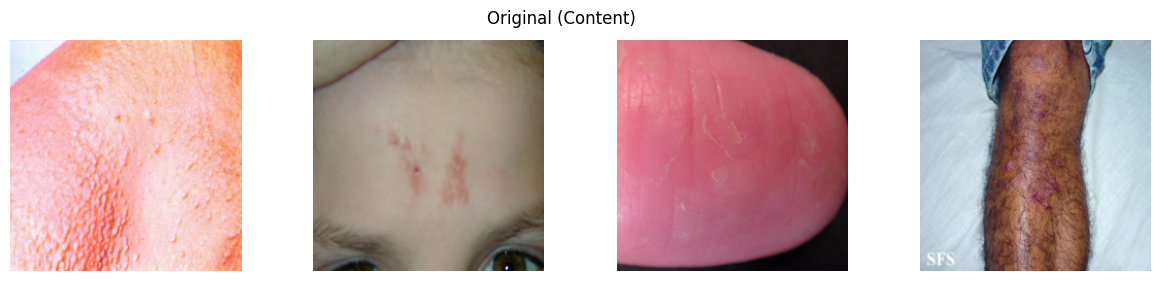

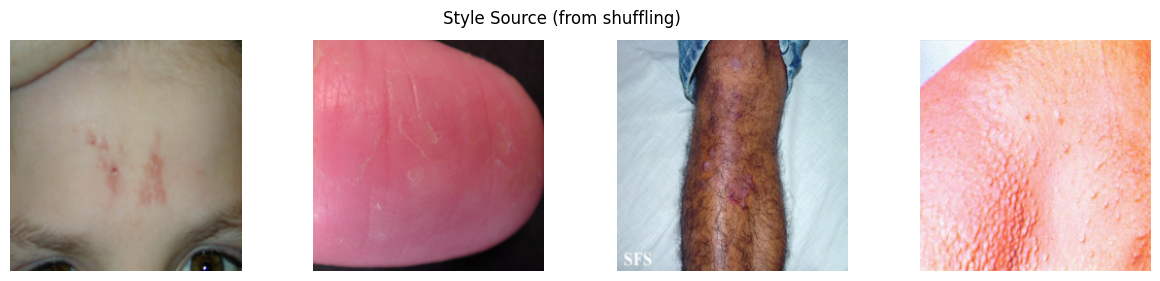

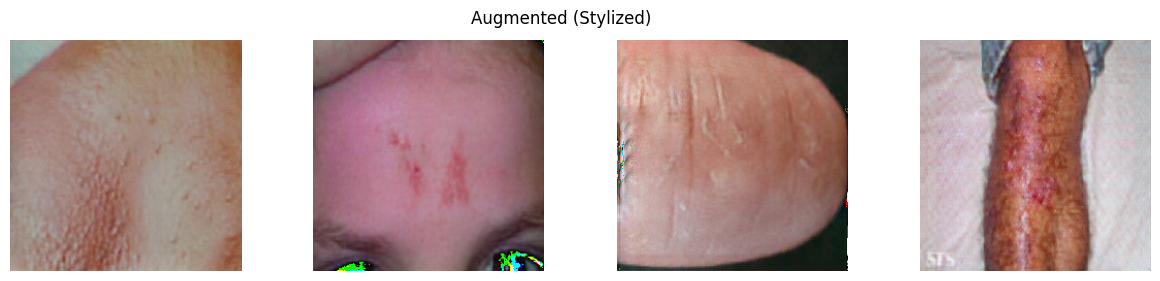

In [36]:
def show_batch(param_tensor, title):
    plt.figure(figsize=(15, 3))
    for i in range(len(param_tensor)):
        plt.subplot(1, 4, i+1)
        img = denormalize_image(param_tensor[i].cpu(), mean=DATASET_MEAN, std=DATASET_STD)
        plt.imshow(transforms.ToPILImage()(img))
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_batch(batch_tensor, "Original (Content)")
show_batch(style_source_batch, "Style Source (from shuffling)")
show_batch(stylized_batch, "Augmented (Stylized)")